In [4]:
import numpy as np
import pandas as pd

# Load the fraud transaction dataset
df = pd.read_csv("fraudTrain.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (19476, 23)

First 5 Rows:
   Unnamed: 0 trans_date_trans_time        cc_num  \
0           0   2019-01-01 00:00:18  2.703186e+15   
1           1   2019-01-01 00:00:44  6.304233e+11   
2           2   2019-01-01 00:00:51  3.885949e+13   
3           3   2019-01-01 00:01:16  3.534094e+15   
4           4   2019-01-01 00:03:06  3.755342e+14   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens 

In [5]:
print("Dataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19476 entries, 0 to 19475
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             19476 non-null  int64  
 1   trans_date_trans_time  19476 non-null  object 
 2   cc_num                 19475 non-null  float64
 3   merchant               19475 non-null  object 
 4   category               19475 non-null  object 
 5   amt                    19475 non-null  float64
 6   first                  19475 non-null  object 
 7   last                   19475 non-null  object 
 8   gender                 19475 non-null  object 
 9   street                 19475 non-null  object 
 10  city                   19475 non-null  object 
 11  state                  19475 non-null  object 
 12  zip                    19475 non-null  float64
 13  lat                    19475 non-null  float64
 14  long                   19475 non-

In [6]:
# Check transaction amount

print("Transaction Amount Statistics:")
print(df["amt"].describe())

Transaction Amount Statistics:
count    19475.000000
mean        70.519926
std        150.263839
min          1.010000
25%          9.630000
50%         48.250000
75%         83.075000
max      11872.210000
Name: amt, dtype: float64


In [7]:
# Equal-width binning of transaction amount

df["Amount_Bin"] = pd.cut(
    df["amt"],
    bins=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

print("Transaction Amount with Bins:")
print(df[["amt", "Amount_Bin"]].head(20))

Transaction Amount with Bins:
       amt Amount_Bin
0     4.97   Very Low
1   107.23   Very Low
2   220.11   Very Low
3    45.00   Very Low
4    41.96   Very Low
5    94.63   Very Low
6    44.54   Very Low
7    71.65   Very Low
8     4.27   Very Low
9   198.39   Very Low
10   24.74   Very Low
11    7.77   Very Low
12   71.22   Very Low
13   96.29   Very Low
14    7.77   Very Low
15    3.26   Very Low
16  327.00   Very Low
17  341.67   Very Low
18   63.07   Very Low
19   44.71   Very Low


In [8]:
print("Number of Transactions in Each Amount Bin:")
print(df["Amount_Bin"].value_counts().sort_index())

Number of Transactions in Each Amount Bin:
Amount_Bin
Very Low     19469
Low              4
Medium           1
High             0
Very High        1
Name: count, dtype: int64


In [9]:
# Quantile-based binning

df["Amount_Quantile_Bin"] = pd.qcut(
    df["amt"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

print(df[["amt", "Amount_Quantile_Bin"]].head(20))

       amt Amount_Quantile_Bin
0     4.97            Very Low
1   107.23           Very High
2   220.11           Very High
3    45.00              Medium
4    41.96              Medium
5    94.63           Very High
6    44.54              Medium
7    71.65                High
8     4.27            Very Low
9   198.39           Very High
10   24.74                 Low
11    7.77                 Low
12   71.22                High
13   96.29           Very High
14    7.77                 Low
15    3.26            Very Low
16  327.00           Very High
17  341.67           Very High
18   63.07                High
19   44.71              Medium


In [10]:
# Compare fraud transactions across amount bins

fraud_by_bin = pd.crosstab(
    df["Amount_Bin"],
    df["is_fraud"]
)

print("Fraud Distribution Across Amount Bins:")
print(fraud_by_bin)

Fraud Distribution Across Amount Bins:
is_fraud      0.0  1.0
Amount_Bin            
Very Low    19337  132
Low             4    0
Medium          1    0
Very High       1    0


In [11]:
print("Average Transaction Amount:")

print(
    df.groupby("is_fraud")["amt"].mean()
)

Average Transaction Amount:
is_fraud
0.0     67.380580
1.0    530.552955
Name: amt, dtype: float64


In [12]:
# Select numerical features

features = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long"
]

print("Selected Features:")
print(df[features].head())

Selected Features:
      amt      lat      long  city_pop  merch_lat  merch_long
0    4.97  36.0788  -81.1781    3495.0  36.011293  -82.048315
1  107.23  48.8878 -118.2105     149.0  49.159047 -118.186462
2  220.11  42.1808 -112.2620    4154.0  43.150704 -112.154481
3   45.00  46.2306 -112.1138    1939.0  47.034331 -112.561071
4   41.96  38.4207  -79.4629      99.0  38.674999  -78.632459


In [13]:
print("Statistics Before Scaling:")
print(df[features].describe())

Statistics Before Scaling:
                amt           lat          long      city_pop     merch_lat  \
count  19475.000000  19475.000000  19475.000000  1.947500e+04  19475.000000   
mean      70.519926     38.499702    -90.362035  9.084999e+04     38.501656   
std      150.263839      5.140518     14.111404  3.028157e+05      5.166165   
min        1.010000     20.027100   -165.672300  2.300000e+01     19.042510   
25%        9.630000     34.668900    -96.917700  7.440000e+02     34.753383   
50%       48.250000     39.303600    -87.591700  2.471000e+03     39.310831   
75%       83.075000     41.811400    -80.158000  2.112500e+04     41.881962   
max    11872.210000     65.689900    -67.950300  2.906700e+06     66.645176   

         merch_long  
count  19475.000000  
mean     -90.358590  
std       14.129925  
min     -166.629875  
25%      -97.038188  
50%      -87.484562  
75%      -80.189566  
max      -66.967742  


In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_minmax = df[features].copy()

df_minmax[features] = scaler.fit_transform(
    df_minmax[features]
)

print("After Min-Max Scaling:")
print(df_minmax.head())

After Min-Max Scaling:
        amt       lat      long  city_pop  merch_lat  merch_long
0  0.000334  0.351527  0.864638  0.001194   0.356467    0.848683
1  0.008948  0.632040  0.485682  0.000043   0.632665    0.486076
2  0.018456  0.485159  0.546553  0.001421   0.506446    0.546601
3  0.003706  0.573848  0.548070  0.000659   0.588031    0.542521
4  0.003450  0.402814  0.882190  0.000026   0.412424    0.882957


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_minmax = df[features].copy()

df_minmax[features] = scaler.fit_transform(
    df_minmax[features]
)

print("After Min-Max Scaling:")
print(df_minmax.head())

After Min-Max Scaling:
        amt       lat      long  city_pop  merch_lat  merch_long
0  0.000334  0.351527  0.864638  0.001194   0.356467    0.848683
1  0.008948  0.632040  0.485682  0.000043   0.632665    0.486076
2  0.018456  0.485159  0.546553  0.001421   0.506446    0.546601
3  0.003706  0.573848  0.548070  0.000659   0.588031    0.542521
4  0.003450  0.402814  0.882190  0.000026   0.412424    0.882957


In [16]:
comparison = pd.DataFrame({
    "Original_Amount": df["amt"].head(10).values,
    "MinMax_Amount": df_minmax["amt"].head(10).values,
    "Standardized_Amount": df_standard["amt"].head(10).values
})

print(comparison)

NameError: name 'df_standard' is not defined

In [17]:
# Log transformation

df["amt_log"] = np.log1p(df["amt"])

print("Original and Log-Transformed Amount:")
print(df[["amt", "amt_log"]].head(20))

Original and Log-Transformed Amount:
       amt   amt_log
0     4.97  1.786747
1   107.23  4.684259
2   220.11  5.398660
3    45.00  3.828641
4    41.96  3.760269
5    94.63  4.560487
6    44.54  3.818591
7    71.65  4.285653
8     4.27  1.662030
9   198.39  5.295263
10   24.74  3.248046
11    7.77  2.171337
12   71.22  4.279717
13   96.29  4.577696
14    7.77  2.171337
15    3.26  1.449269
16  327.00  5.793014
17  341.67  5.836768
18   63.07  4.159976
19   44.71  3.822317


In [18]:
# Square root transformation

df["amt_sqrt"] = np.sqrt(df["amt"])

print("Original and Square Root Transformed Amount:")
print(df[["amt", "amt_sqrt"]].head(20))

Original and Square Root Transformed Amount:
       amt   amt_sqrt
0     4.97   2.229350
1   107.23  10.355192
2   220.11  14.836105
3    45.00   6.708204
4    41.96   6.477654
5    94.63   9.727795
6    44.54   6.673829
7    71.65   8.464632
8     4.27   2.066398
9   198.39  14.085099
10   24.74   4.973932
11    7.77   2.787472
12   71.22   8.439194
13   96.29   9.812747
14    7.77   2.787472
15    3.26   1.805547
16  327.00  18.083141
17  341.67  18.484318
18   63.07   7.941662
19   44.71   6.686554


In [19]:
# Calculate Q1 and Q3

Q1 = df["amt"].quantile(0.25)
Q3 = df["amt"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 9.63
Q3: 83.07499999999999
IQR: 73.445


In [20]:
# Calculate lower and upper limits

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -100.5375
Upper Limit: 193.24249999999998


In [22]:
# Detect transaction amount outliers

outliers = df[
    (df["amt"] < lower_limit) |
    (df["amt"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

print("\nFirst 20 Outliers:")
print(
    outliers[
        ["amt", "category", "city", "is_fraud"]
    ].head(20)
)

Number of Outliers: 1003

First 20 Outliers:
         amt       category              city  is_fraud
2     220.11  entertainment        Malad City       0.0
9     198.39    grocery_pos       Clarksville       0.0
16    327.00       misc_net            Lahoma       0.0
17    341.67   shopping_pos          Carlisle       0.0
36    207.36    grocery_pos          Bellmore       0.0
39    221.81    grocery_pos          Moriches       0.0
43    212.75    grocery_pos           Holcomb       0.0
54    212.45    grocery_pos               Jay       0.0
67    303.47       misc_net            Cranks       0.0
73    317.14   shopping_pos             Parks       0.0
82    218.71       misc_pos         Littleton       0.0
108   226.33   shopping_net         June Lake       0.0
109   215.99   shopping_net             Sixes       0.0
138   636.41   shopping_pos           Ozawkie       0.0
139   500.92   shopping_net        Blackville       0.0
165   204.72    grocery_pos        Saint Paul       0.0
229

In [23]:
# Detect transaction amount outliers

outliers = df[
    (df["amt"] < lower_limit) |
    (df["amt"] > upper_limit)
]

print("Number of Outliers:", len(outliers))

print("\nFirst 20 Outliers:")
print(
    outliers[
        ["amt", "category", "city", "is_fraud"]
    ].head(20)
)

Number of Outliers: 1003

First 20 Outliers:
         amt       category              city  is_fraud
2     220.11  entertainment        Malad City       0.0
9     198.39    grocery_pos       Clarksville       0.0
16    327.00       misc_net            Lahoma       0.0
17    341.67   shopping_pos          Carlisle       0.0
36    207.36    grocery_pos          Bellmore       0.0
39    221.81    grocery_pos          Moriches       0.0
43    212.75    grocery_pos           Holcomb       0.0
54    212.45    grocery_pos               Jay       0.0
67    303.47       misc_net            Cranks       0.0
73    317.14   shopping_pos             Parks       0.0
82    218.71       misc_pos         Littleton       0.0
108   226.33   shopping_net         June Lake       0.0
109   215.99   shopping_net             Sixes       0.0
138   636.41   shopping_pos           Ozawkie       0.0
139   500.92   shopping_net        Blackville       0.0
165   204.72    grocery_pos        Saint Paul       0.0
229

In [30]:
# Complete IQR Outlier Detection and Fraud Comparison

# Calculate Q1 and Q3
Q1 = df["amt"].quantile(0.25)
Q3 = df["amt"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Create outlier column
df["Amount_Outlier"] = np.where(
    (df["amt"] < lower_limit) |
    (df["amt"] > upper_limit),
    1,
    0
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

print("\nTotal Outliers:")
print(df["Amount_Outlier"].sum())

# Compare outliers with actual fraud
comparison = pd.crosstab(
    df["Amount_Outlier"],
    df["is_fraud"]
)

print("\nOutlier vs Fraud Comparison:")
print(comparison)

Q1: 9.63
Q3: 83.07499999999999
IQR: 73.445
Lower Limit: -100.5375
Upper Limit: 193.24249999999998

Total Outliers:
1003

Outlier vs Fraud Comparison:
is_fraud          0.0  1.0
Amount_Outlier            
0               18444   28
1                 899  104


In [31]:
# Select only outlier transactions

outlier_data = df[
    df["Amount_Outlier"] == 1
]

fraud_rate = outlier_data["is_fraud"].mean() * 100

print("Total Outlier Transactions:", len(outlier_data))

print(
    "Fraud Rate Among Outlier Transactions:",
    round(fraud_rate, 2),
    "%"
)

Total Outlier Transactions: 1003
Fraud Rate Among Outlier Transactions: 10.37 %


In [32]:
# Select non-outlier transactions

normal_data = df[
    df["Amount_Outlier"] == 0
]

normal_fraud_rate = normal_data["is_fraud"].mean() * 100

print("Total Non-Outlier Transactions:", len(normal_data))

print(
    "Fraud Rate Among Non-Outlier Transactions:",
    round(normal_fraud_rate, 2),
    "%"
)

Total Non-Outlier Transactions: 18473
Fraud Rate Among Non-Outlier Transactions: 0.15 %


In [33]:
# Select non-outlier transactions

normal_data = df[
    df["Amount_Outlier"] == 0
]

normal_fraud_rate = normal_data["is_fraud"].mean() * 100

print("Total Non-Outlier Transactions:", len(normal_data))

print(
    "Fraud Rate Among Non-Outlier Transactions:",
    round(normal_fraud_rate, 2),
    "%"
)

Total Non-Outlier Transactions: 18473
Fraud Rate Among Non-Outlier Transactions: 0.15 %


In [34]:
# Complete IQR Outlier Detection and Fraud Comparison

# Calculate Q1 and Q3
Q1 = df["amt"].quantile(0.25)
Q3 = df["amt"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Create outlier column
df["Amount_Outlier"] = np.where(
    (df["amt"] < lower_limit) |
    (df["amt"] > upper_limit),
    1,
    0
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

print("\nTotal Outliers:")
print(df["Amount_Outlier"].sum())

# Compare outliers with actual fraud
comparison = pd.crosstab(
    df["Amount_Outlier"],
    df["is_fraud"]
)

print("\nOutlier vs Fraud Comparison:")
print(comparison)

Q1: 9.63
Q3: 83.07499999999999
IQR: 73.445
Lower Limit: -100.5375
Upper Limit: 193.24249999999998

Total Outliers:
1003

Outlier vs Fraud Comparison:
is_fraud          0.0  1.0
Amount_Outlier            
0               18444   28
1                 899  104


In [38]:
from scipy.stats import zscore

# Calculate Z-score for transaction amount
df["Amount_ZScore"] = zscore(df["amt"])

# Create Z-score outlier column
df["ZScore_Outlier"] = np.where(
    np.abs(df["Amount_ZScore"]) > 3,
    1,
    0
)

# Count Z-score outliers
zscore_outlier_count = df["ZScore_Outlier"].sum()

print("Number of Z-Score Outliers:", zscore_outlier_count)

print("\nSample Results:")
print(
    df[
        ["amt", "Amount_ZScore", "ZScore_Outlier", "is_fraud"]
    ].head(20)
)

Number of Z-Score Outliers: 0

Sample Results:
       amt  Amount_ZScore  ZScore_Outlier  is_fraud
0     4.97            NaN               0       0.0
1   107.23            NaN               0       0.0
2   220.11            NaN               0       0.0
3    45.00            NaN               0       0.0
4    41.96            NaN               0       0.0
5    94.63            NaN               0       0.0
6    44.54            NaN               0       0.0
7    71.65            NaN               0       0.0
8     4.27            NaN               0       0.0
9   198.39            NaN               0       0.0
10   24.74            NaN               0       0.0
11    7.77            NaN               0       0.0
12   71.22            NaN               0       0.0
13   96.29            NaN               0       0.0
14    7.77            NaN               0       0.0
15    3.26            NaN               0       0.0
16  327.00            NaN               0       0.0
17  341.67       

In [39]:
# Count Z-score outliers

print(
    "Number of Z-Score Outliers:",
    df["ZScore_Outlier"].sum()
)

Number of Z-Score Outliers: 0


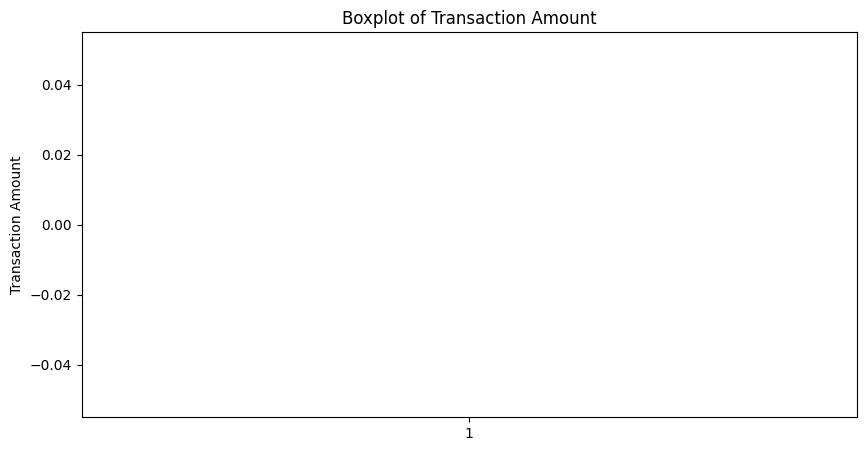

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(df["amt"])

plt.title("Boxplot of Transaction Amount")
plt.ylabel("Transaction Amount")

plt.show()

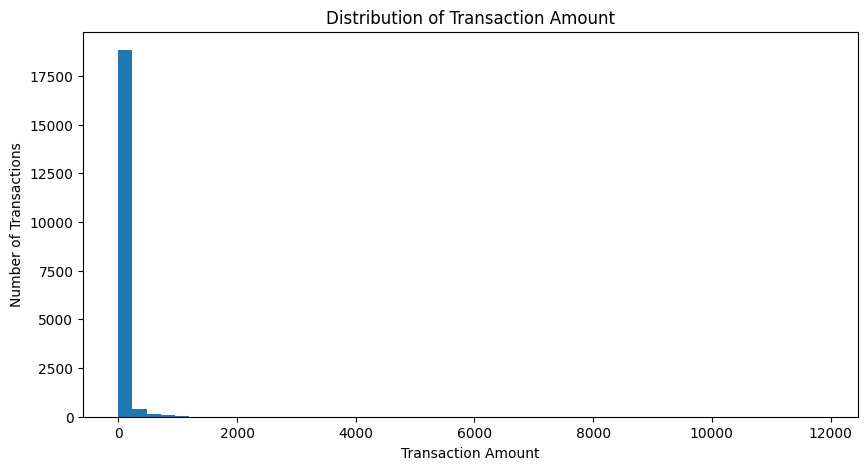

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(df["amt"], bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

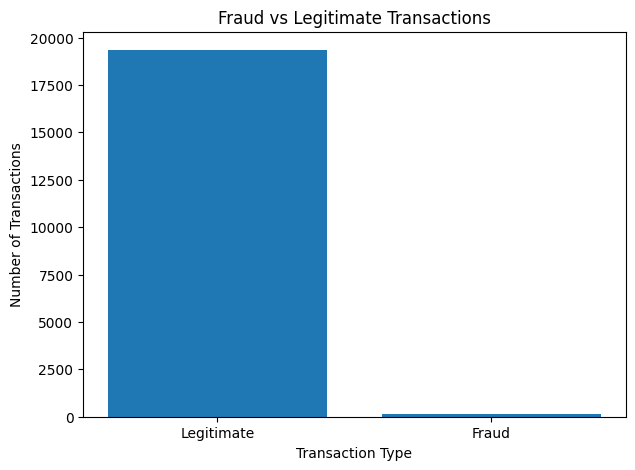

In [42]:
fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Legitimate", "Fraud"],
    fraud_counts.reindex([0, 1])
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()